In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from datetime import timedelta
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans


Sales_raw = pd.read_csv('https://docs.google.com/spreadsheets/d/e/2PACX-1vTLMncqJYOX8o3Gf8oHWGMinXjvSXlzufhyS6Bv8tvpe4b5siWSPIpWgQyEdKWIvtbnIBJtKTqM-Z6M/pub?gid=1363795325&single=true&output=csv')
Customers_raw = pd.read_csv('https://docs.google.com/spreadsheets/d/e/2PACX-1vTLMncqJYOX8o3Gf8oHWGMinXjvSXlzufhyS6Bv8tvpe4b5siWSPIpWgQyEdKWIvtbnIBJtKTqM-Z6M/pub?gid=1009534267&single=true&output=csv')
Products_raw= pd.read_csv('https://docs.google.com/spreadsheets/d/e/2PACX-1vTLMncqJYOX8o3Gf8oHWGMinXjvSXlzufhyS6Bv8tvpe4b5siWSPIpWgQyEdKWIvtbnIBJtKTqM-Z6M/pub?gid=146490797&single=true&output=csv')
Stores_raw = pd.read_csv('https://docs.google.com/spreadsheets/d/e/2PACX-1vTLMncqJYOX8o3Gf8oHWGMinXjvSXlzufhyS6Bv8tvpe4b5siWSPIpWgQyEdKWIvtbnIBJtKTqM-Z6M/pub?gid=1917011079&single=true&output=csv')
Exchange_rates_raw = pd.read_csv('https://docs.google.com/spreadsheets/d/e/2PACX-1vTLMncqJYOX8o3Gf8oHWGMinXjvSXlzufhyS6Bv8tvpe4b5siWSPIpWgQyEdKWIvtbnIBJtKTqM-Z6M/pub?gid=153895806&single=true&output=csv')


# Data Exploration


## Sales


In [ ]:
Sales_raw

,Order Number,Line Item,Order Date,Delivery Date,CustomerKey,StoreKey,ProductKey,Quantity,Currency Code
0,366000,1,1/1/2016,NaN,265598,10,1304,1,CAD
1,366001,1,1/1/2016,1/13/2016,1269051,0,1048,2,USD
2,366001,2,1/1/2016,1/13/2016,1269051,0,2007,1,USD
3,366002,1,1/1/2016,1/12/2016,266019,0,1106,7,CAD
4,366002,2,1/1/2016,1/12/2016,266019,0,373,1,CAD
...,...,...,...,...,...,...,...,...,...
62879,2243030,1,2/20/2021,NaN,1216913,43,632,3,USD
62880,2243031,1,2/20/2021,2/24/2021,511229,0,98,4,EUR
62881,2243032,1,2/20/2021,2/23/2021,331277,0,1613,2,CAD
62882,2243032,2,2/20/2021,2/23/2021,331277,0,1717,2,CAD


In [ ]:
Sales_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 62884 entries, 0 to 62883
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Order Number   62884 non-null  int64 
 1   Line Item      62884 non-null  int64 
 2   Order Date     62884 non-null  object
 3   Delivery Date  13165 non-null  object
 4   CustomerKey    62884 non-null  int64 
 5   StoreKey       62884 non-null  int64 
 6   ProductKey     62884 non-null  int64 
 7   Quantity       62884 non-null  int64 
 8   Currency Code  62884 non-null  object
dtypes: int64(6), object(3)
memory usage: 4.3+ MB


In [ ]:
Sales_raw.isnull().sum()

,0
Order Number,0
Line Item,0
Order Date,0
Delivery Date,49719
CustomerKey,0
StoreKey,0
ProductKey,0
Quantity,0
Currency Code,0


In [ ]:
Sales_raw.isnull().mean() * 100

,0
Order Number,0.000000
Line Item,0.000000
Order Date,0.000000
Delivery Date,79.064627
CustomerKey,0.000000
StoreKey,0.000000
ProductKey,0.000000
Quantity,0.000000
Currency Code,0.000000


In [ ]:
Sales_raw.describe()

,Order Number,Line Item,CustomerKey,StoreKey,ProductKey,Quantity
count,6.288400e+04,62884.000000,6.288400e+04,62884.000000,62884.000000,62884.000000
mean,1.430905e+06,2.164207,1.180797e+06,31.802144,1125.859344,3.144790
std,4.532963e+05,1.365170,5.859634e+05,22.978188,709.244010,2.256371
min,3.660000e+05,1.000000,3.010000e+02,0.000000,1.000000,1.000000
25%,1.121017e+06,1.000000,6.808580e+05,8.000000,437.000000,1.000000
50%,1.498016e+06,2.000000,1.261200e+06,37.000000,1358.000000,2.000000
75%,1.788010e+06,3.000000,1.686496e+06,53.000000,1650.000000,4.000000
max,2.243032e+06,7.000000,2.099937e+06,66.000000,2517.000000,10.000000


In [ ]:
Sales_raw["Order Number"].unique()

array([ 366000,  366001,  366002, ..., 2243030, 2243031, 2243032])

In [ ]:
Sales_raw["Quantity"].sort_values(ascending = True)

,Quantity
42830,1
62865,1
62864,1
62861,1
62856,1
...,...
17796,10
54668,10
25444,10
61034,10


<Axes: >

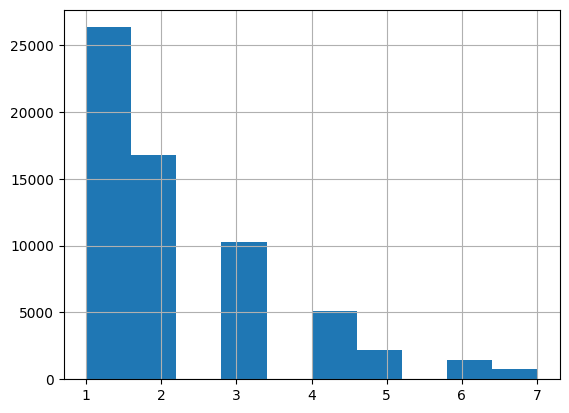

In [ ]:
Sales_raw['Line Item'].hist()

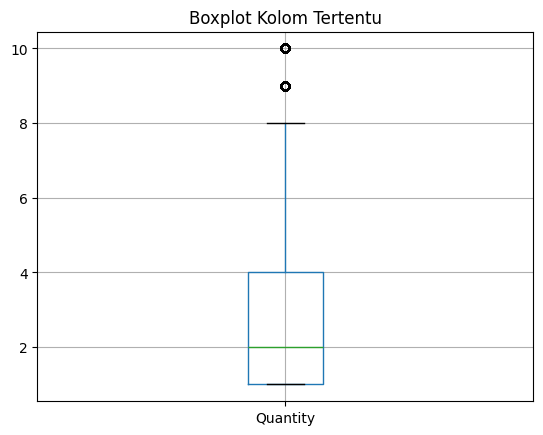

In [ ]:
Sales_raw.boxplot(column=['Quantity'])

plt.title('Boxplot Kolom Tertentu')
plt.show()

##Customers

In [ ]:
Customers_raw

,CustomerKey,Gender,Name,City,State Code,State,Zip Code,Country,Continent,Birthday
0,301,Female,Lilly Harding,WANDEARAH EAST,SA,South Australia,5523,Australia,Australia,7/3/1939
1,325,Female,Madison Hull,MOUNT BUDD,WA,Western Australia,6522,Australia,Australia,9/27/1979
2,554,Female,Claire Ferres,WINJALLOK,VIC,Victoria,3380,Australia,Australia,5/26/1947
3,786,Male,Jai Poltpalingada,MIDDLE RIVER,SA,South Australia,5223,Australia,Australia,9/17/1957
4,1042,Male,Aidan Pankhurst,TAWONGA SOUTH,VIC,Victoria,3698,Australia,Australia,11/19/1965
...,...,...,...,...,...,...,...,...,...,...
15261,2099600,Female,Denisa Du�kov�,Houston,TX,Texas,77017,United States,North America,3/25/1936
15262,2099618,Male,Justin Sol�rzano,Mclean,VA,Virginia,22101,United States,North America,2/16/1992
15263,2099758,Male,Svend Petrussen,Wilmington,NC,North Carolina,28405,United States,North America,11/9/1937
15264,2099862,Female,Lorenza Rush,Riverside,CA,California,92501,United States,North America,10/12/1937


In [ ]:
Customers_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15266 entries, 0 to 15265
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   CustomerKey  15266 non-null  int64 
 1   Gender       15266 non-null  object
 2   Name         15266 non-null  object
 3   City         15266 non-null  object
 4   State Code   15256 non-null  object
 5   State        15266 non-null  object
 6   Zip Code     15266 non-null  object
 7   Country      15266 non-null  object
 8   Continent    15266 non-null  object
 9   Birthday     15266 non-null  object
dtypes: int64(1), object(9)
memory usage: 1.2+ MB


In [ ]:
Customers_raw.isnull().sum()

,0
CustomerKey,0
Gender,0
Name,0
City,0
State Code,10
State,0
Zip Code,0
Country,0
Continent,0
Birthday,0


In [ ]:
Customers_null = Customers_raw[Customers_raw['State Code'].isnull()]

Customers_null

,CustomerKey,Gender,Name,City,State Code,State,Zip Code,Country,Continent,Birthday
5304,729681,Female,Rossana Padovesi,Polvica,NaN,Napoli,80035,Italy,Europe,4/18/1981
5316,732289,Male,Indro Piccio,Varcaturo,NaN,Napoli,80014,Italy,Europe,2/24/1949
5372,742042,Male,Amaranto Loggia,Casaferro,NaN,Napoli,80034,Italy,Europe,3/14/1936
5377,742886,Female,Edmonda Capon,Terzigno,NaN,Napoli,80040,Italy,Europe,8/6/1963
5378,743343,Female,Ambra Sagese,Pomigliano D'Arco,NaN,Napoli,80038,Italy,Europe,1/5/1961
5485,759705,Male,Callisto Lo Duca,Casilli,NaN,Napoli,80047,Italy,Europe,8/28/1976
5525,765589,Male,Michelino Lucchesi,Pompei Scavi,NaN,Napoli,80045,Italy,Europe,11/13/1947
5531,766410,Male,Adelmio Beneventi,Licola,NaN,Napoli,80078,Italy,Europe,1/13/1940
5631,781667,Female,Ilda Manna,Napoli,NaN,Napoli,80134,Italy,Europe,5/8/1977
5695,789177,Male,Calogero Folliero,Mariglianella,NaN,Napoli,80030,Italy,Europe,3/3/2000


In [ ]:
Customer_Napoli = Customers_raw[Customers_raw['State Code'] == 'NA']

Customer_Napoli

,CustomerKey,Gender,Name,City,State Code,State,Zip Code,Country,Continent,Birthday


In [ ]:
Customers_raw.isnull().mean()*100

,0
CustomerKey,0.000000
Gender,0.000000
Name,0.000000
City,0.000000
State Code,0.065505
State,0.000000
Zip Code,0.000000
Country,0.000000
Continent,0.000000
Birthday,0.000000


In [ ]:
Customers_raw.duplicated().sum()

np.int64(0)

In [ ]:
Customers_raw['Continent'].value_counts()

,count
Continent,
North America,8381
Europe,5465
Australia,1420


##Products


In [ ]:
Products_raw

,ProductKey,Product Name,Brand,Color,Unit Cost USD,Unit Price USD,SubcategoryKey,Subcategory,CategoryKey,Category
0,1,Contoso 512MB MP3 Player E51 Silver,Contoso,Silver,$6.62,$12.99,101,MP4&MP3,1,Audio
1,2,Contoso 512MB MP3 Player E51 Blue,Contoso,Blue,$6.62,$12.99,101,MP4&MP3,1,Audio
2,3,Contoso 1G MP3 Player E100 White,Contoso,White,$7.40,$14.52,101,MP4&MP3,1,Audio
3,4,Contoso 2G MP3 Player E200 Silver,Contoso,Silver,$11.00,$21.57,101,MP4&MP3,1,Audio
4,5,Contoso 2G MP3 Player E200 Red,Contoso,Red,$11.00,$21.57,101,MP4&MP3,1,Audio
...,...,...,...,...,...,...,...,...,...,...
2512,2513,Contoso Bluetooth Active Headphones L15 Red,Contoso,Red,$43.07,$129.99,505,Cell phones Accessories,5,Cell phones
2513,2514,Contoso Bluetooth Active Headphones L15 White,Contoso,White,$43.07,$129.99,505,Cell phones Accessories,5,Cell phones
2514,2515,Contoso In-Line Coupler E180 White,Contoso,White,$1.71,$3.35,505,Cell phones Accessories,5,Cell phones
2515,2516,Contoso In-Line Coupler E180 Black,Contoso,Black,$1.71,$3.35,505,Cell phones Accessories,5,Cell phones


In [ ]:
Products_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2517 entries, 0 to 2516
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   ProductKey      2517 non-null   int64 
 1   Product Name    2517 non-null   object
 2   Brand           2517 non-null   object
 3   Color           2517 non-null   object
 4   Unit Cost USD   2517 non-null   object
 5   Unit Price USD  2517 non-null   object
 6   SubcategoryKey  2517 non-null   int64 
 7   Subcategory     2517 non-null   object
 8   CategoryKey     2517 non-null   int64 
 9   Category        2517 non-null   object
dtypes: int64(3), object(7)
memory usage: 196.8+ KB


In [ ]:
Products_raw.isnull().sum()

,0
ProductKey,0
Product Name,0
Brand,0
Color,0
Unit Cost USD,0
Unit Price USD,0
SubcategoryKey,0
Subcategory,0
CategoryKey,0
Category,0


In [ ]:
Products_raw.duplicated().sum()

np.int64(0)

In [ ]:
Products_raw['Category'].value_counts()

,count
Category,
Home Appliances,661
Computers,606
Cameras and camcorders,372
Cell phones,285
TV and Video,222
Games and Toys,166
Audio,115
"Music, Movies and Audio Books",90


##Stores


In [ ]:
Stores_raw

,StoreKey,Country,State,Square Meters,Open Date
0,1,Australia,Australian Capital Territory,595.0,1/1/2008
1,2,Australia,Northern Territory,665.0,1/12/2008
2,3,Australia,South Australia,2000.0,1/7/2012
3,4,Australia,Tasmania,2000.0,1/1/2010
4,5,Australia,Victoria,2000.0,12/9/2015
...,...,...,...,...,...
62,63,United States,Utah,2000.0,3/6/2008
63,64,United States,Washington DC,1330.0,1/1/2010
64,65,United States,West Virginia,1785.0,1/1/2012
65,66,United States,Wyoming,840.0,1/1/2014


In [ ]:
Stores_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 67 entries, 0 to 66
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   StoreKey       67 non-null     int64  
 1   Country        67 non-null     object 
 2   State          67 non-null     object 
 3   Square Meters  66 non-null     float64
 4   Open Date      67 non-null     object 
dtypes: float64(1), int64(1), object(3)
memory usage: 2.7+ KB


In [ ]:
Stores_raw.isnull().sum()

,0
StoreKey,0
Country,0
State,0
Square Meters,1
Open Date,0


In [ ]:
Stores_null =Stores_raw[Stores_raw['Square Meters'].isnull()]

Stores_null

,StoreKey,Country,State,Square Meters,Open Date
66,0,Online,Online,NaN,1/1/2010


In [ ]:
Stores_raw.duplicated().sum()

np.int64(0)

In [ ]:
Stores_raw['Country'].value_counts()

,count
Country,
United States,24
Germany,9
United Kingdom,7
France,7
Australia,6
Netherlands,5
Canada,5
Italy,3
Online,1


## Exchange Rate

In [ ]:
Exchange_rates_raw

,Date,Currency,Exchange
0,1/1/2015,USD,1.0000
1,1/1/2015,CAD,1.1583
2,1/1/2015,AUD,1.2214
3,1/1/2015,EUR,0.8237
4,1/1/2015,GBP,0.6415
...,...,...,...
11210,2/20/2021,USD,1.0000
11211,2/20/2021,CAD,1.2610
11212,2/20/2021,AUD,1.2723
11213,2/20/2021,EUR,0.8238


In [ ]:
Exchange_rates_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11215 entries, 0 to 11214
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Date      11215 non-null  object 
 1   Currency  11215 non-null  object 
 2   Exchange  11215 non-null  float64
dtypes: float64(1), object(2)
memory usage: 263.0+ KB


# Data Cleaning And Manipulation

## Sales

In [ ]:
Sales = Sales_raw.copy()

Sales

,Order Number,Line Item,Order Date,Delivery Date,CustomerKey,StoreKey,ProductKey,Quantity,Currency Code
0,366000,1,1/1/2016,NaN,265598,10,1304,1,CAD
1,366001,1,1/1/2016,1/13/2016,1269051,0,1048,2,USD
2,366001,2,1/1/2016,1/13/2016,1269051,0,2007,1,USD
3,366002,1,1/1/2016,1/12/2016,266019,0,1106,7,CAD
4,366002,2,1/1/2016,1/12/2016,266019,0,373,1,CAD
...,...,...,...,...,...,...,...,...,...
62879,2243030,1,2/20/2021,NaN,1216913,43,632,3,USD
62880,2243031,1,2/20/2021,2/24/2021,511229,0,98,4,EUR
62881,2243032,1,2/20/2021,2/23/2021,331277,0,1613,2,CAD
62882,2243032,2,2/20/2021,2/23/2021,331277,0,1717,2,CAD


In [ ]:
#Menghapus kolom Delivery date, karena null lebih dari 50%

Sales = Sales.drop(columns='Delivery Date')

In [ ]:
Sales['CustomerKey'] = Sales['CustomerKey'].astype(str)

In [ ]:
Sales['Order Number'] = Sales['Order Number'].astype(str)

In [ ]:
# Mengubah kolom 'date' menjadi tipe datetime

Sales['Order Date'] = pd.to_datetime(Sales['Order Date'])


In [ ]:
# Menambah kolom tahun, bulan, hari

Sales['Year'] = Sales['Order Date'].dt.year
Sales['Month'] = Sales['Order Date'].dt.month
Sales['Date'] = Sales['Order Date'].dt.day
Sales['Day'] = Sales['Order Date'].dt.day_name()
#

In [ ]:
Sales

,Order Number,Line Item,Order Date,CustomerKey,StoreKey,ProductKey,Quantity,Currency Code,Year,Month,Date,Day
0,366000,1,2016-01-01,265598,10,1304,1,CAD,2016,1,1,Friday
1,366001,1,2016-01-01,1269051,0,1048,2,USD,2016,1,1,Friday
2,366001,2,2016-01-01,1269051,0,2007,1,USD,2016,1,1,Friday
3,366002,1,2016-01-01,266019,0,1106,7,CAD,2016,1,1,Friday
4,366002,2,2016-01-01,266019,0,373,1,CAD,2016,1,1,Friday
...,...,...,...,...,...,...,...,...,...,...,...,...
62879,2243030,1,2021-02-20,1216913,43,632,3,USD,2021,2,20,Saturday
62880,2243031,1,2021-02-20,511229,0,98,4,EUR,2021,2,20,Saturday
62881,2243032,1,2021-02-20,331277,0,1613,2,CAD,2021,2,20,Saturday
62882,2243032,2,2021-02-20,331277,0,1717,2,CAD,2021,2,20,Saturday


In [ ]:
Sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 62884 entries, 0 to 62883
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Order Number   62884 non-null  object        
 1   Line Item      62884 non-null  int64         
 2   Order Date     62884 non-null  datetime64[ns]
 3   CustomerKey    62884 non-null  object        
 4   StoreKey       62884 non-null  int64         
 5   ProductKey     62884 non-null  int64         
 6   Quantity       62884 non-null  int64         
 7   Currency Code  62884 non-null  object        
 8   Year           62884 non-null  int32         
 9   Month          62884 non-null  int32         
 10  Date           62884 non-null  int32         
 11  Day            62884 non-null  object        
dtypes: datetime64[ns](1), int32(3), int64(4), object(4)
memory usage: 5.0+ MB


## Customers

In [ ]:
pd.reset_option('display.max_rows')
Customers = Customers_raw.copy()
Customers

,CustomerKey,Gender,Name,City,State Code,State,Zip Code,Country,Continent,Birthday
0,301,Female,Lilly Harding,WANDEARAH EAST,SA,South Australia,5523,Australia,Australia,7/3/1939
1,325,Female,Madison Hull,MOUNT BUDD,WA,Western Australia,6522,Australia,Australia,9/27/1979
2,554,Female,Claire Ferres,WINJALLOK,VIC,Victoria,3380,Australia,Australia,5/26/1947
3,786,Male,Jai Poltpalingada,MIDDLE RIVER,SA,South Australia,5223,Australia,Australia,9/17/1957
4,1042,Male,Aidan Pankhurst,TAWONGA SOUTH,VIC,Victoria,3698,Australia,Australia,11/19/1965
...,...,...,...,...,...,...,...,...,...,...
15261,2099600,Female,Denisa Du�kov�,Houston,TX,Texas,77017,United States,North America,3/25/1936
15262,2099618,Male,Justin Sol�rzano,Mclean,VA,Virginia,22101,United States,North America,2/16/1992
15263,2099758,Male,Svend Petrussen,Wilmington,NC,North Carolina,28405,United States,North America,11/9/1937
15264,2099862,Female,Lorenza Rush,Riverside,CA,California,92501,United States,North America,10/12/1937


In [ ]:
kolom_kotor = ['Name', 'City']

for col in kolom_kotor:
  Customers[col] = Customers[col].str.strip().str.replace(r'\s+', ' ', regex=True).str.title()


In [ ]:
Customers['CustomerKey'] = Customers['CustomerKey'].astype(str)

In [ ]:
Customers

,CustomerKey,Gender,Name,City,State Code,State,Zip Code,Country,Continent,Birthday
0,301,Female,Lilly Harding,Wandearah East,SA,South Australia,5523,Australia,Australia,7/3/1939
1,325,Female,Madison Hull,Mount Budd,WA,Western Australia,6522,Australia,Australia,9/27/1979
2,554,Female,Claire Ferres,Winjallok,VIC,Victoria,3380,Australia,Australia,5/26/1947
3,786,Male,Jai Poltpalingada,Middle River,SA,South Australia,5223,Australia,Australia,9/17/1957
4,1042,Male,Aidan Pankhurst,Tawonga South,VIC,Victoria,3698,Australia,Australia,11/19/1965
...,...,...,...,...,...,...,...,...,...,...
15261,2099600,Female,Denisa Du�Kov�,Houston,TX,Texas,77017,United States,North America,3/25/1936
15262,2099618,Male,Justin Sol�Rzano,Mclean,VA,Virginia,22101,United States,North America,2/16/1992
15263,2099758,Male,Svend Petrussen,Wilmington,NC,North Carolina,28405,United States,North America,11/9/1937
15264,2099862,Female,Lorenza Rush,Riverside,CA,California,92501,United States,North America,10/12/1937


In [ ]:
#Mengisi State code yang kosong

Customers.loc[(Customers['State Code'].isnull()) & (Customers['State'] == 'Napoli'), 'State Code'] = 'NA'

Customers

,CustomerKey,Gender,Name,City,State Code,State,Zip Code,Country,Continent,Birthday
0,301,Female,Lilly Harding,Wandearah East,SA,South Australia,5523,Australia,Australia,7/3/1939
1,325,Female,Madison Hull,Mount Budd,WA,Western Australia,6522,Australia,Australia,9/27/1979
2,554,Female,Claire Ferres,Winjallok,VIC,Victoria,3380,Australia,Australia,5/26/1947
3,786,Male,Jai Poltpalingada,Middle River,SA,South Australia,5223,Australia,Australia,9/17/1957
4,1042,Male,Aidan Pankhurst,Tawonga South,VIC,Victoria,3698,Australia,Australia,11/19/1965
...,...,...,...,...,...,...,...,...,...,...
15261,2099600,Female,Denisa Du�Kov�,Houston,TX,Texas,77017,United States,North America,3/25/1936
15262,2099618,Male,Justin Sol�Rzano,Mclean,VA,Virginia,22101,United States,North America,2/16/1992
15263,2099758,Male,Svend Petrussen,Wilmington,NC,North Carolina,28405,United States,North America,11/9/1937
15264,2099862,Female,Lorenza Rush,Riverside,CA,California,92501,United States,North America,10/12/1937


In [ ]:
Customers['Birthday'] =pd.to_datetime(Customers["Birthday"])

In [ ]:
Customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15266 entries, 0 to 15265
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   CustomerKey  15266 non-null  object        
 1   Gender       15266 non-null  object        
 2   Name         15266 non-null  object        
 3   City         15266 non-null  object        
 4   State Code   15266 non-null  object        
 5   State        15266 non-null  object        
 6   Zip Code     15266 non-null  object        
 7   Country      15266 non-null  object        
 8   Continent    15266 non-null  object        
 9   Birthday     15266 non-null  datetime64[ns]
dtypes: datetime64[ns](1), object(9)
memory usage: 1.2+ MB


## Products


In [ ]:
Products = Products_raw.copy()

Products

,ProductKey,Product Name,Brand,Color,Unit Cost USD,Unit Price USD,SubcategoryKey,Subcategory,CategoryKey,Category
0,1,Contoso 512MB MP3 Player E51 Silver,Contoso,Silver,$6.62,$12.99,101,MP4&MP3,1,Audio
1,2,Contoso 512MB MP3 Player E51 Blue,Contoso,Blue,$6.62,$12.99,101,MP4&MP3,1,Audio
2,3,Contoso 1G MP3 Player E100 White,Contoso,White,$7.40,$14.52,101,MP4&MP3,1,Audio
3,4,Contoso 2G MP3 Player E200 Silver,Contoso,Silver,$11.00,$21.57,101,MP4&MP3,1,Audio
4,5,Contoso 2G MP3 Player E200 Red,Contoso,Red,$11.00,$21.57,101,MP4&MP3,1,Audio
...,...,...,...,...,...,...,...,...,...,...
2512,2513,Contoso Bluetooth Active Headphones L15 Red,Contoso,Red,$43.07,$129.99,505,Cell phones Accessories,5,Cell phones
2513,2514,Contoso Bluetooth Active Headphones L15 White,Contoso,White,$43.07,$129.99,505,Cell phones Accessories,5,Cell phones
2514,2515,Contoso In-Line Coupler E180 White,Contoso,White,$1.71,$3.35,505,Cell phones Accessories,5,Cell phones
2515,2516,Contoso In-Line Coupler E180 Black,Contoso,Black,$1.71,$3.35,505,Cell phones Accessories,5,Cell phones


In [ ]:
Products['Unit Price USD'] = Products['Unit Price USD'].str.replace('$', '', regex=False).str.replace(',', '', regex=False).astype(float)

In [ ]:
Products['Unit Cost USD'] = Products['Unit Cost USD'].str.replace('$', '', regex=False).str.replace(',', '', regex=False).astype(float)

In [ ]:
Products.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2517 entries, 0 to 2516
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   ProductKey      2517 non-null   int64  
 1   Product Name    2517 non-null   object 
 2   Brand           2517 non-null   object 
 3   Color           2517 non-null   object 
 4   Unit Cost USD   2517 non-null   float64
 5   Unit Price USD  2517 non-null   float64
 6   SubcategoryKey  2517 non-null   int64  
 7   Subcategory     2517 non-null   object 
 8   CategoryKey     2517 non-null   int64  
 9   Category        2517 non-null   object 
dtypes: float64(2), int64(3), object(5)
memory usage: 196.8+ KB


## Exchange Rate


In [ ]:
Exchange_rate = Exchange_rates_raw.copy()


Exchange_rate

,Date,Currency,Exchange
0,1/1/2015,USD,1.0000
1,1/1/2015,CAD,1.1583
2,1/1/2015,AUD,1.2214
3,1/1/2015,EUR,0.8237
4,1/1/2015,GBP,0.6415
...,...,...,...
11210,2/20/2021,USD,1.0000
11211,2/20/2021,CAD,1.2610
11212,2/20/2021,AUD,1.2723
11213,2/20/2021,EUR,0.8238


In [ ]:
# Merubah format date

Exchange_rate['Date'] = pd.to_datetime(Exchange_rate['Date'])



In [ ]:
Exchange_rate

,Date,Currency,Exchange
0,2015-01-01,USD,1.0000
1,2015-01-01,CAD,1.1583
2,2015-01-01,AUD,1.2214
3,2015-01-01,EUR,0.8237
4,2015-01-01,GBP,0.6415
...,...,...,...
11210,2021-02-20,USD,1.0000
11211,2021-02-20,CAD,1.2610
11212,2021-02-20,AUD,1.2723
11213,2021-02-20,EUR,0.8238


# Data Transformation


In [ ]:
## Menggabungkan tabel Sales, Customers, dan Exchange

In [ ]:
df_merged = pd.merge(Sales, Customers, on='CustomerKey', how='left')
df_merged = pd.merge(df_merged, Exchange_rate.rename(columns={'Date': 'Order Date', 'Currency': 'Currency Code'}), on=['Order Date', 'Currency Code'], how='left')
df_merged = pd.merge(df_merged, Products, on='ProductKey', how='left')

df_merged

,Order Number,Line Item,Order Date,CustomerKey,StoreKey,ProductKey,Quantity,Currency Code,Year,Month,...,Exchange,Product Name,Brand,Color,Unit Cost USD,Unit Price USD,SubcategoryKey,Subcategory,CategoryKey,Category
0,366000,1,2016-01-01,265598,10,1304,1,CAD,2016,1,...,1.3884,Contoso Lens Adapter M450 White,Contoso,White,31.27,68.00,406,Cameras & Camcorders Accessories,4,Cameras and camcorders
1,366001,1,2016-01-01,1269051,0,1048,2,USD,2016,1,...,1.0000,A. Datum SLR Camera X136 Silver,A. Datum,Silver,141.47,427.00,402,Digital SLR Cameras,4,Cameras and camcorders
2,366001,2,2016-01-01,1269051,0,2007,1,USD,2016,1,...,1.0000,Fabrikam Microwave 1.5CuFt X1100 Black,Fabrikam,Black,220.64,665.94,803,Microwaves,8,Home Appliances
3,366002,1,2016-01-01,266019,0,1106,7,CAD,2016,1,...,1.3884,Contoso SLR Camera M146 Orange,Contoso,Orange,148.08,322.00,402,Digital SLR Cameras,4,Cameras and camcorders
4,366002,2,2016-01-01,266019,0,373,1,CAD,2016,1,...,1.3884,Adventure Works Laptop8.9 E0890 White,Adventure Works,White,166.20,326.00,301,Laptops,3,Computers
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
62879,2243030,1,2021-02-20,1216913,43,632,3,USD,2021,2,...,1.0000,WWI Screen 85in E1010 White,Wide World Importers,White,70.87,139.00,305,Projectors & Screens,3,Computers
62880,2243031,1,2021-02-20,511229,0,98,4,EUR,2021,2,...,0.8238,WWI Wireless Bluetooth Stereo Headphones M170 ...,Wide World Importers,Silver,55.18,120.00,106,Bluetooth Headphones,1,Audio
62881,2243032,1,2021-02-20,331277,0,1613,2,CAD,2021,2,...,1.2610,SV DVD 7-Inch Player Portable E200 White,Southridge Video,White,56.08,109.99,602,Movie DVD,6,"Music, Movies and Audio Books"
62882,2243032,2,2021-02-20,331277,0,1717,2,CAD,2021,2,...,1.2610,MGS Flight Simulator X M250,Tailspin Toys,Pink,32.25,70.13,702,Download Games,7,Games and Toys


In [ ]:
snapshot_date = df_merged["Order Date"].max()
snapshot_date



Timestamp('2021-02-20 00:00:00')

In [ ]:
df_merged['Age'] = (snapshot_date - df_merged['Birthday']).dt.days / 365.25

In [ ]:
df_merged.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 62884 entries, 0 to 62883
Data columns (total 32 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Order Number    62884 non-null  object        
 1   Line Item       62884 non-null  int64         
 2   Order Date      62884 non-null  datetime64[ns]
 3   CustomerKey     62884 non-null  object        
 4   StoreKey        62884 non-null  int64         
 5   ProductKey      62884 non-null  int64         
 6   Quantity        62884 non-null  int64         
 7   Currency Code   62884 non-null  object        
 8   Year            62884 non-null  int32         
 9   Month           62884 non-null  int32         
 10  Date            62884 non-null  int32         
 11  Day             62884 non-null  object        
 12  Gender          62884 non-null  object        
 13  Name            62884 non-null  object        
 14  City            62884 non-null  object        
 15  St

In [ ]:
df = df_merged[['Order Number', 'Order Date','CustomerKey', 'Name', 'Gender', 'City', 'State', 'Country', 'Continent', 'Birthday','Age', 'Product Name', 'Brand', 'Color', 'Category', 'Subcategory', 'Exchange', 'Unit Cost USD', 'Unit Price USD', 'Quantity', 'Year', 'Month', 'Date', 'Day']]


In [ ]:
df

,Order Number,Order Date,CustomerKey,Name,Gender,City,State,Country,Continent,Birthday,...,Category,Subcategory,Exchange,Unit Cost USD,Unit Price USD,Quantity,Year,Month,Date,Day
0,366000,2016-01-01,265598,Tyler Vaught,Male,London,Ontario,Canada,North America,1971-03-23,...,Cameras and camcorders,Cameras & Camcorders Accessories,1.3884,31.27,68.00,1,2016,1,1,Friday
1,366001,2016-01-01,1269051,Frank Upchurch,Male,Auberry,California,United States,North America,1995-11-20,...,Cameras and camcorders,Digital SLR Cameras,1.0000,141.47,427.00,2,2016,1,1,Friday
2,366001,2016-01-01,1269051,Frank Upchurch,Male,Auberry,California,United States,North America,1995-11-20,...,Home Appliances,Microwaves,1.0000,220.64,665.94,1,2016,1,1,Friday
3,366002,2016-01-01,266019,Joan Roche,Female,Red Deer,Alberta,Canada,North America,1962-08-24,...,Cameras and camcorders,Digital SLR Cameras,1.3884,148.08,322.00,7,2016,1,1,Friday
4,366002,2016-01-01,266019,Joan Roche,Female,Red Deer,Alberta,Canada,North America,1962-08-24,...,Computers,Laptops,1.3884,166.20,326.00,1,2016,1,1,Friday
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
62879,2243030,2021-02-20,1216913,Donald Woodie,Male,Garden Grove,California,United States,North America,1939-04-16,...,Computers,Projectors & Screens,1.0000,70.87,139.00,3,2021,2,20,Saturday
62880,2243031,2021-02-20,511229,Gabriele Thalberg,Female,Stuttgart Frauenkopf,Baden-W�rttemberg,Germany,Europe,1940-03-10,...,Audio,Bluetooth Headphones,0.8238,55.18,120.00,4,2021,2,20,Saturday
62881,2243032,2021-02-20,331277,William Rochelle,Male,Calgary,Alberta,Canada,North America,1993-05-25,...,"Music, Movies and Audio Books",Movie DVD,1.2610,56.08,109.99,2,2021,2,20,Saturday
62882,2243032,2021-02-20,331277,William Rochelle,Male,Calgary,Alberta,Canada,North America,1993-05-25,...,Games and Toys,Download Games,1.2610,32.25,70.13,2,2021,2,20,Saturday


In [ ]:
df['Revenue'] = df['Quantity'] * df['Unit Price USD']

/tmp/ipykernel_2058/2776040014.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Revenue'] = df['Quantity'] * df['Unit Price USD']


In [ ]:
df['Age'] = df["Age"].astype(int)

/tmp/ipykernel_2058/504952359.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Age'] = df["Age"].astype(int)


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 62884 entries, 0 to 62883
Data columns (total 25 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Order Number    62884 non-null  object        
 1   Order Date      62884 non-null  datetime64[ns]
 2   CustomerKey     62884 non-null  object        
 3   Name            62884 non-null  object        
 4   Gender          62884 non-null  object        
 5   City            62884 non-null  object        
 6   State           62884 non-null  object        
 7   Country         62884 non-null  object        
 8   Continent       62884 non-null  object        
 9   Birthday        62884 non-null  datetime64[ns]
 10  Age             62884 non-null  int64         
 11  Product Name    62884 non-null  object        
 12  Brand           62884 non-null  object        
 13  Color           62884 non-null  object        
 14  Category        62884 non-null  object        
 15  Su

#Customer Segmentation


## RFM grouping


In [ ]:


rfm_df = df.groupby('CustomerKey').agg(
    Recency=('Order Date', lambda date: (snapshot_date - date.max()).days),
    Frequency=('Order Number', 'count'),
    Monetary=('Revenue', 'sum'),

)


rfm_df

,Recency,Frequency,Monetary
CustomerKey,,,
1000050,364,4,1292.97
1000168,476,10,10160.86
1000242,904,4,8010.96
100040,905,3,4158.00
1000489,789,10,3739.61
...,...,...,...
999485,1148,3,266.72
999589,222,4,3162.00
999701,737,3,1152.17


## Quartile Calculation

In [ ]:
r_q1 = rfm_df["Recency"].quantile(0.25)
r_q2 = rfm_df["Recency"].quantile(0.50)
r_q3 = rfm_df["Recency"].quantile(0.75)

f_q1 = rfm_df["Frequency"].quantile(0.25)
f_q2 = rfm_df["Frequency"].quantile(0.50)
f_q3 = rfm_df["Frequency"].quantile(0.75)

m_q1 = rfm_df["Monetary"].quantile(0.25)
m_q2 = rfm_df["Monetary"].quantile(0.50)
m_q3 = rfm_df["Monetary"].quantile(0.75)

In [ ]:
def r_score(x):
    if x <= r_q1:
        return 4
    elif x <= r_q2:
        return 3
    elif x <= r_q3:
        return 2
    else:
        return 1

def f_score(x):
    if x <= f_q1:
        return 1
    elif x <= f_q2:
        return 2
    elif x <= f_q3:
        return 3
    else:
        return 4

def m_score(x):
    if x <= m_q1:
        return 1
    elif x <= m_q2:
        return 2
    elif x <= m_q3:
        return 3
    else:
        return 4

In [ ]:
rfm_df["R"] = rfm_df["Recency"].apply(r_score)
rfm_df["F"] = rfm_df["Frequency"].apply(f_score)
rfm_df["M"] = rfm_df["Monetary"].apply(m_score)

In [ ]:
rfm_df.head()

,Recency,Frequency,Monetary,R,F,M
CustomerKey,,,,,,
1000050,364,4,1292.97,4,2,2
1000168,476,10,10160.86,3,4,4
1000242,904,4,8010.96,1,2,4
100040,905,3,4158.00,1,2,3
1000489,789,10,3739.61,2,4,3


In [ ]:
rfm_df["Total_Score"] = rfm_df["R"] + rfm_df["F"] + rfm_df["M"]
rfm_df.head()

,Recency,Frequency,Monetary,R,F,M,Total_Score
CustomerKey,,,,,,,
1000050,364,4,1292.97,4,2,2,8
1000168,476,10,10160.86,3,4,4,11
1000242,904,4,8010.96,1,2,4,7
100040,905,3,4158.00,1,2,3,6
1000489,789,10,3739.61,2,4,3,9


##Segment Definition


In [ ]:
def segment(score):
    if score >= 10:
        return "Best Customer"
    elif score >= 8:
        return "Loyal Customer"
    elif score >= 6:
        return "Potential Customer"
    elif score >= 4:
        return "At Risk"
    else:
        return "Lost Customer"

rfm_df["Segment"] = rfm_df["Total_Score"].apply(segment)
rfm_df.head()

,Recency,Frequency,Monetary,R,F,M,Total_Score,Segment
CustomerKey,,,,,,,,
1000050,364,4,1292.97,4,2,2,8,Loyal Customer
1000168,476,10,10160.86,3,4,4,11,Best Customer
1000242,904,4,8010.96,1,2,4,7,Potential Customer
100040,905,3,4158.00,1,2,3,6,Potential Customer
1000489,789,10,3739.61,2,4,3,9,Loyal Customer


# Menggabungkan kedua data


In [ ]:
df_rfm = pd.merge(df, rfm_df, on='CustomerKey', how='left')

In [ ]:
df_rfm

,Order Number,Order Date,CustomerKey,Name,Gender,City,State,Country,Continent,Birthday,...,Day,Revenue,Recency,Frequency,Monetary,R,F,M,Total_Score,Segment
0,366000,2016-01-01,265598,Tyler Vaught,Male,London,Ontario,Canada,North America,1971-03-23,...,Friday,68.00,494,8,1461.43,3,4,2,9,Loyal Customer
1,366001,2016-01-01,1269051,Frank Upchurch,Male,Auberry,California,United States,North America,1995-11-20,...,Friday,854.00,1877,2,1519.94,1,1,2,4,At Risk
2,366001,2016-01-01,1269051,Frank Upchurch,Male,Auberry,California,United States,North America,1995-11-20,...,Friday,665.94,1877,2,1519.94,1,1,2,4,At Risk
3,366002,2016-01-01,266019,Joan Roche,Female,Red Deer,Alberta,Canada,North America,1962-08-24,...,Friday,2254.00,774,6,8002.00,2,3,4,9,Loyal Customer
4,366002,2016-01-01,266019,Joan Roche,Female,Red Deer,Alberta,Canada,North America,1962-08-24,...,Friday,326.00,774,6,8002.00,2,3,4,9,Loyal Customer
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
62879,2243030,2021-02-20,1216913,Donald Woodie,Male,Garden Grove,California,United States,North America,1939-04-16,...,Saturday,417.00,0,13,14499.82,4,4,4,12,Best Customer
62880,2243031,2021-02-20,511229,Gabriele Thalberg,Female,Stuttgart Frauenkopf,Baden-W�rttemberg,Germany,Europe,1940-03-10,...,Saturday,480.00,0,2,496.99,4,1,1,6,Potential Customer
62881,2243032,2021-02-20,331277,William Rochelle,Male,Calgary,Alberta,Canada,North America,1993-05-25,...,Saturday,219.98,0,9,8126.65,4,4,4,12,Best Customer
62882,2243032,2021-02-20,331277,William Rochelle,Male,Calgary,Alberta,Canada,North America,1993-05-25,...,Saturday,140.26,0,9,8126.65,4,4,4,12,Best Customer


In [ ]:
df_rfm.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 62884 entries, 0 to 62883
Data columns (total 33 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Order Number    62884 non-null  object        
 1   Order Date      62884 non-null  datetime64[ns]
 2   CustomerKey     62884 non-null  object        
 3   Name            62884 non-null  object        
 4   Gender          62884 non-null  object        
 5   City            62884 non-null  object        
 6   State           62884 non-null  object        
 7   Country         62884 non-null  object        
 8   Continent       62884 non-null  object        
 9   Birthday        62884 non-null  datetime64[ns]
 10  Age             62884 non-null  int64         
 11  Product Name    62884 non-null  object        
 12  Brand           62884 non-null  object        
 13  Color           62884 non-null  object        
 14  Category        62884 non-null  object        
 15  Su

In [ ]:
df_export2 = df_rfm

df_export2

,Order Number,Order Date,CustomerKey,Name,Gender,City,State,Country,Continent,Birthday,...,Day,Revenue,Recency,Frequency,Monetary,R,F,M,Total_Score,Segment
0,366000,2016-01-01,265598,Tyler Vaught,Male,London,Ontario,Canada,North America,1971-03-23,...,Friday,68.00,494,8,1461.43,3,4,2,9,Loyal Customer
1,366001,2016-01-01,1269051,Frank Upchurch,Male,Auberry,California,United States,North America,1995-11-20,...,Friday,854.00,1877,2,1519.94,1,1,2,4,At Risk
2,366001,2016-01-01,1269051,Frank Upchurch,Male,Auberry,California,United States,North America,1995-11-20,...,Friday,665.94,1877,2,1519.94,1,1,2,4,At Risk
3,366002,2016-01-01,266019,Joan Roche,Female,Red Deer,Alberta,Canada,North America,1962-08-24,...,Friday,2254.00,774,6,8002.00,2,3,4,9,Loyal Customer
4,366002,2016-01-01,266019,Joan Roche,Female,Red Deer,Alberta,Canada,North America,1962-08-24,...,Friday,326.00,774,6,8002.00,2,3,4,9,Loyal Customer
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
62879,2243030,2021-02-20,1216913,Donald Woodie,Male,Garden Grove,California,United States,North America,1939-04-16,...,Saturday,417.00,0,13,14499.82,4,4,4,12,Best Customer
62880,2243031,2021-02-20,511229,Gabriele Thalberg,Female,Stuttgart Frauenkopf,Baden-W�rttemberg,Germany,Europe,1940-03-10,...,Saturday,480.00,0,2,496.99,4,1,1,6,Potential Customer
62881,2243032,2021-02-20,331277,William Rochelle,Male,Calgary,Alberta,Canada,North America,1993-05-25,...,Saturday,219.98,0,9,8126.65,4,4,4,12,Best Customer
62882,2243032,2021-02-20,331277,William Rochelle,Male,Calgary,Alberta,Canada,North America,1993-05-25,...,Saturday,140.26,0,9,8126.65,4,4,4,12,Best Customer


In [ ]:
df_export2.to_csv('df_export2.csv', index=False)

# Exploratory Data Analysis


## Univariate Analysis

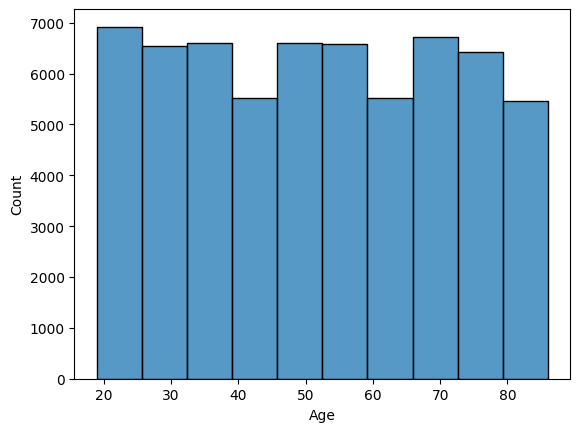

In [ ]:
## for numerinal variable

sns.histplot(df['Age'], bins=10)
plt.show()

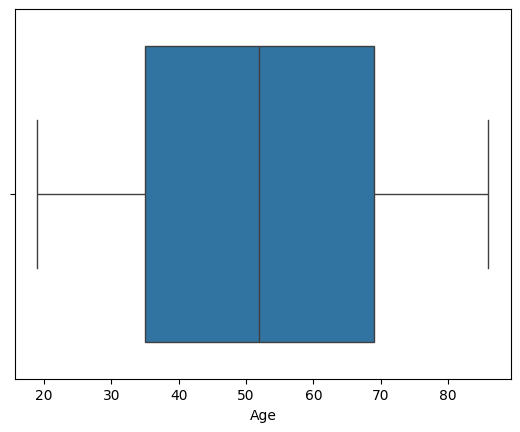

In [ ]:
sns.boxplot(x=df['Age'])
plt.show()

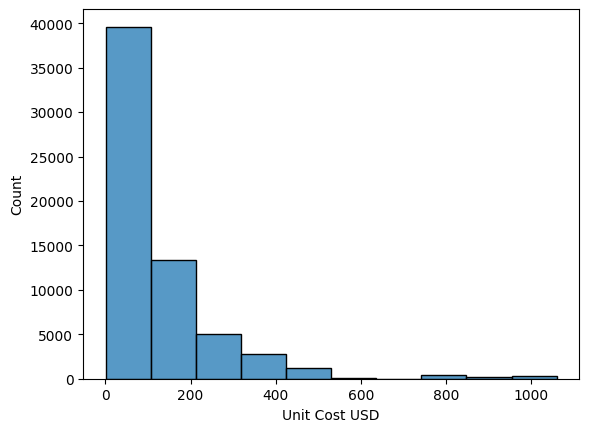

In [ ]:
sns.histplot(df['Unit Cost USD'], bins=10)
plt.show()

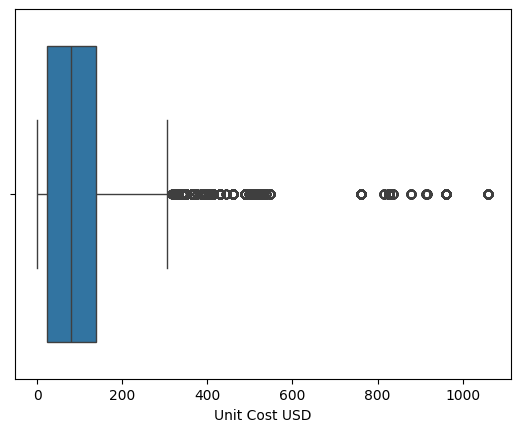

In [ ]:
sns.boxplot(x=df['Unit Cost USD'])
plt.show()

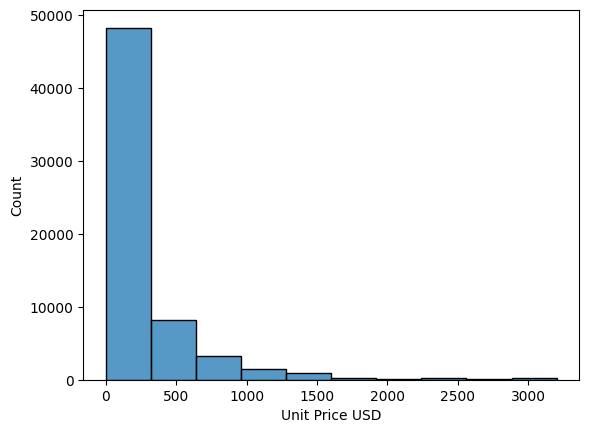

In [ ]:
sns.histplot(df['Unit Price USD'], bins=10)
plt.show()

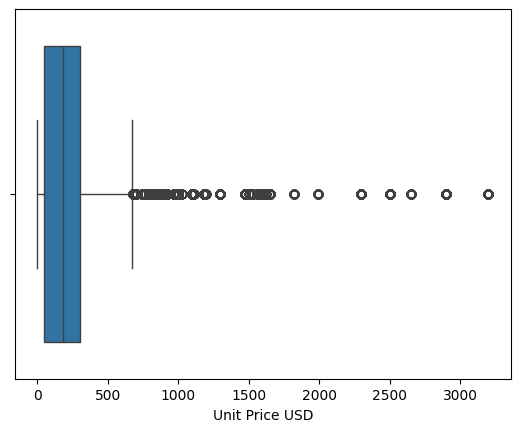

In [ ]:
sns.boxplot(x=df['Unit Price USD'])
plt.show()

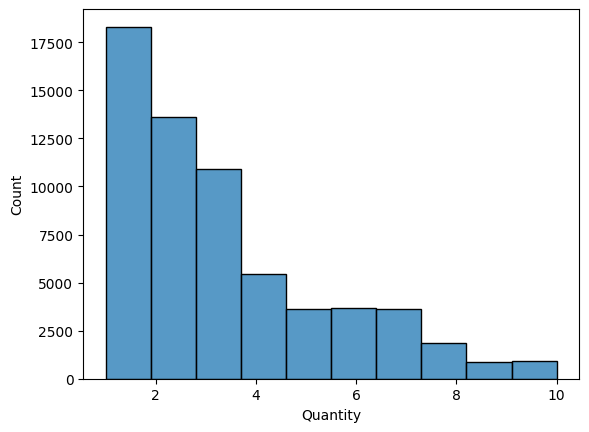

In [ ]:
sns.histplot(df['Quantity'], bins=10)
plt.show()

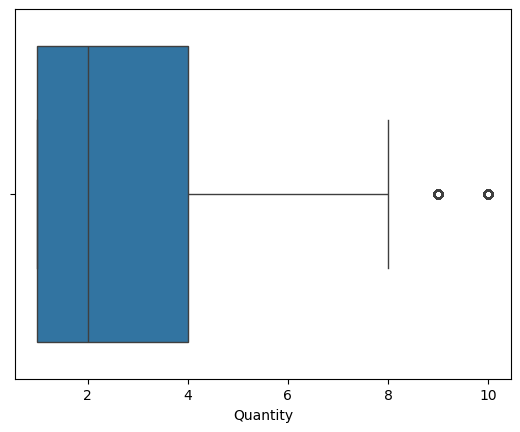

In [ ]:
sns.boxplot(x=df['Quantity'])
plt.show()

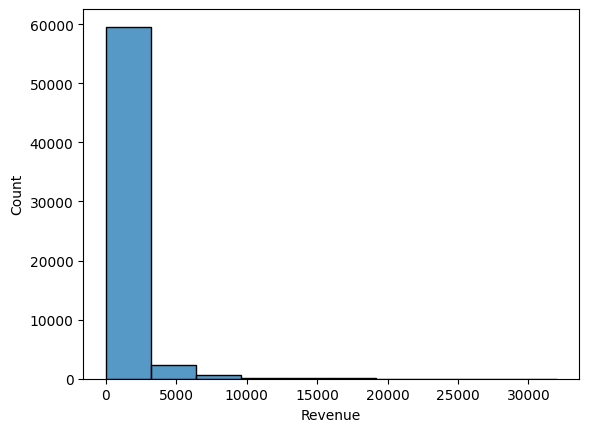

In [ ]:
sns.histplot(df['Revenue'], bins=10)
plt.show()

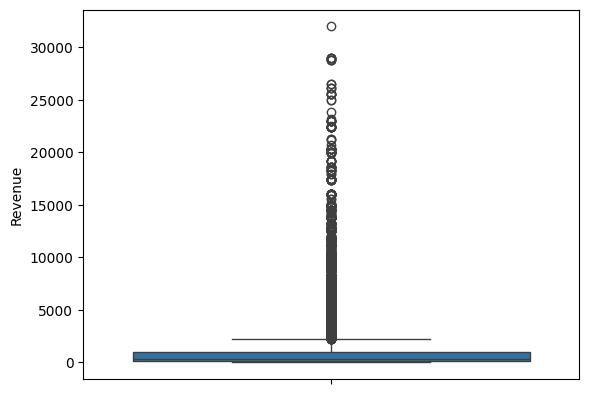

In [ ]:
sns.boxplot(df['Revenue'])
plt.show()

## Bivariate analysis


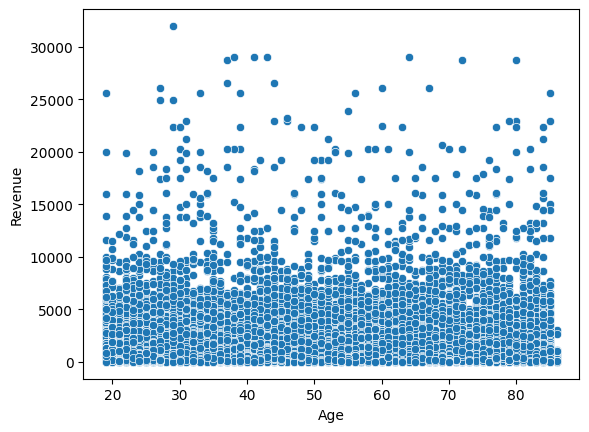

In [ ]:
sns.scatterplot(x='Age', y='Revenue', data=df)
plt.show()

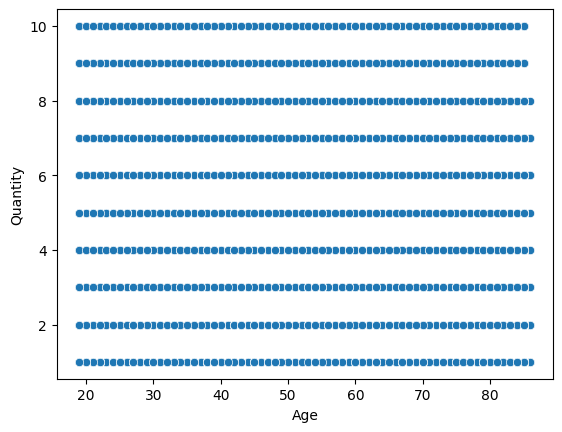

In [ ]:
sns.scatterplot(x='Age', y='Quantity', data=df)
plt.show()

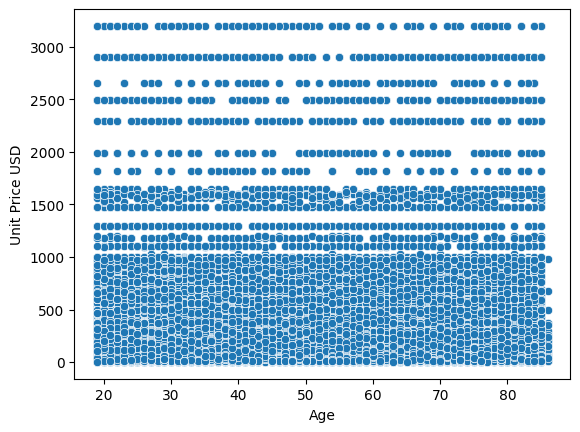

In [ ]:
sns.scatterplot(x='Age', y='Unit Price USD', data=df)
plt.show()

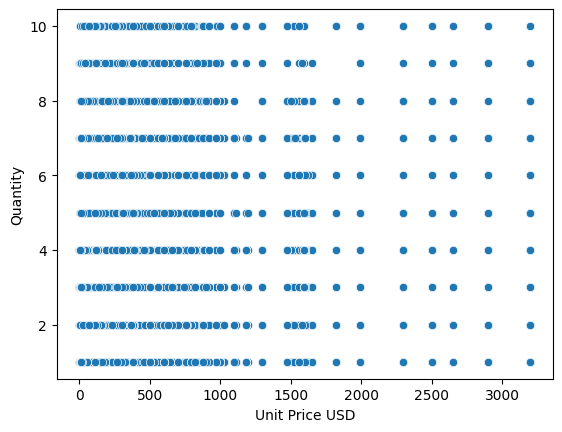

In [ ]:
sns.scatterplot(x='Unit Price USD', y='Quantity', data=df)
plt.show()

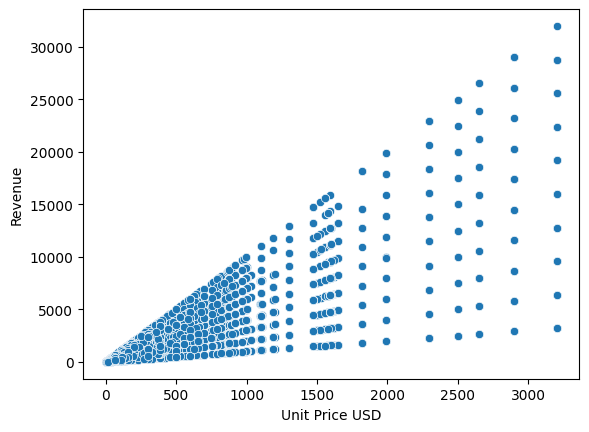

In [ ]:
sns.scatterplot(x='Unit Price USD', y='Revenue', data=df)
plt.show()

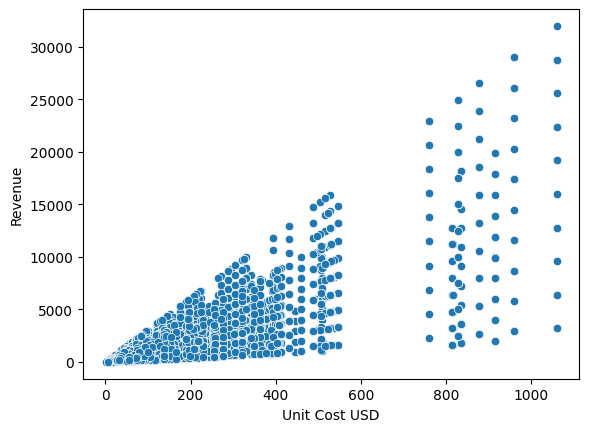

In [ ]:
sns.scatterplot(x='Unit Cost USD', y='Revenue', data=df)
plt.show()

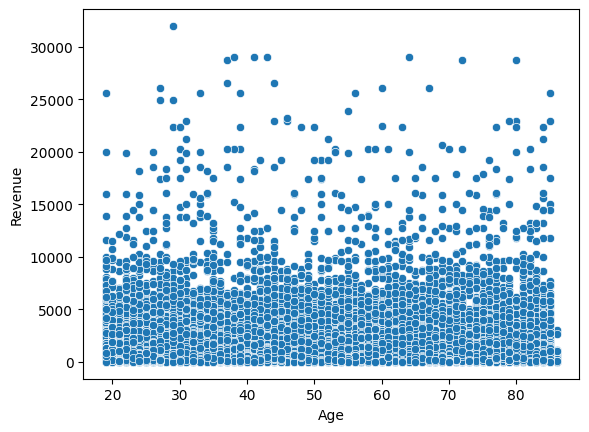

In [ ]:
sns.scatterplot(x='Age', y='Revenue', data=df)
plt.show()

## Mulitivariate analysis


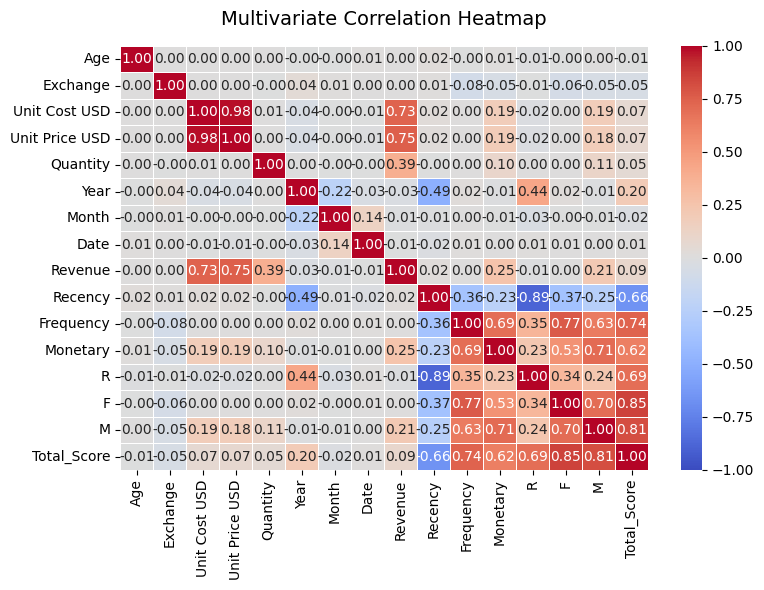

In [ ]:
import numpy as np
# 2. Calculate the Pearson correlation matrix
# This measures linear relationships between all pairs of variables (-1 to 1)
corr_matrix = df_rfm.select_dtypes(include=[np.number]).corr()

# 3. Set up the matplotlib figure size
plt.figure(figsize=(8, 6))

# 4. Generate the heatmap
sns.heatmap(
    corr_matrix,
    annot=True,  # Show correlation values inside each cell
    cmap="coolwarm",  # Diverging color palette (blue = negative, red = positive)
    vmin=-1,  # Anchor the minimum value of the color scale
    vmax=1,  # Anchor the maximum value of the color scale
    linewidths=0.5,  # Add space between cells for clean formatting
    fmt=".2f"  # Round cell values to 2 decimal places
)

# 5. Add custom details and display
plt.title("Multivariate Correlation Heatmap", fontsize=14, pad=15)
plt.tight_layout()
plt.savefig('Heatmap Correlation')
plt.show()


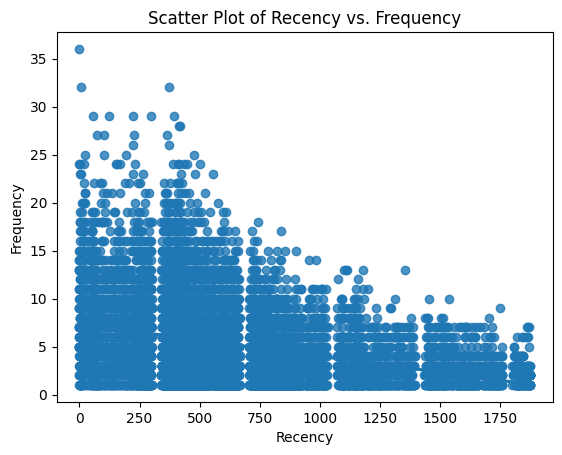

In [ ]:
sns.regplot(x=rfm_df['Recency'], y=rfm_df['Frequency'], ci=None)  # ci=None untuk menghilangkan area interval kepercayaan (confidence interval)

# Menampilkan judul dan label
plt.title("Scatter Plot of Recency vs. Frequency")
plt.xlabel("Recency")
plt.ylabel("Frequency")

# Menampilkan grafik
plt.savefig('Scatter Plot Recency vs Frequency')
plt.show()

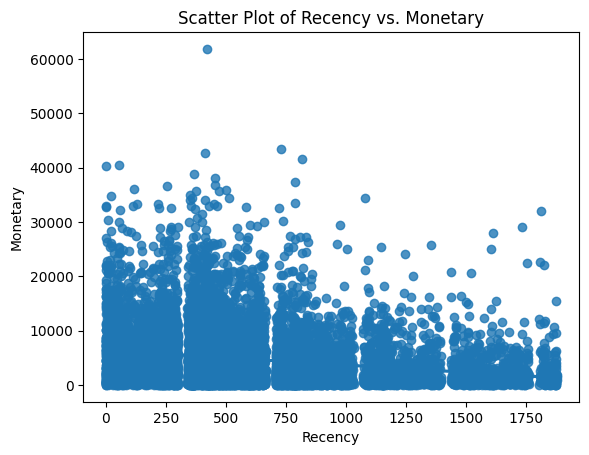

In [ ]:
sns.regplot(x=rfm_df['Recency'], y=rfm_df['Monetary'], ci=None)  # ci=None untuk menghilangkan area interval kepercayaan (confidence interval)

# Menampilkan judul dan label
plt.title("Scatter Plot of Recency vs. Monetary")
plt.xlabel("Recency")
plt.ylabel("Monetary")

# Menampilkan grafik
plt.savefig('Scatter Plot Recency vs Monetary')
plt.show()

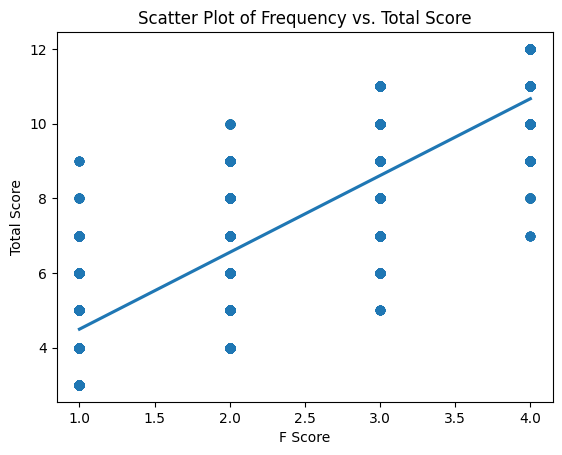

In [ ]:
sns.regplot(x=rfm_df['F'], y=rfm_df['Total_Score'], ci=None)  # ci=None untuk menghilangkan area interval kepercayaan (confidence interval)

# Menampilkan judul dan label
plt.title("Scatter Plot of Frequency vs. Total Score")
plt.xlabel("F Score")
plt.ylabel("Total Score")

# Menampilkan grafik
plt.savefig('Scatter Plot Frequency vs Total Score')
plt.show()

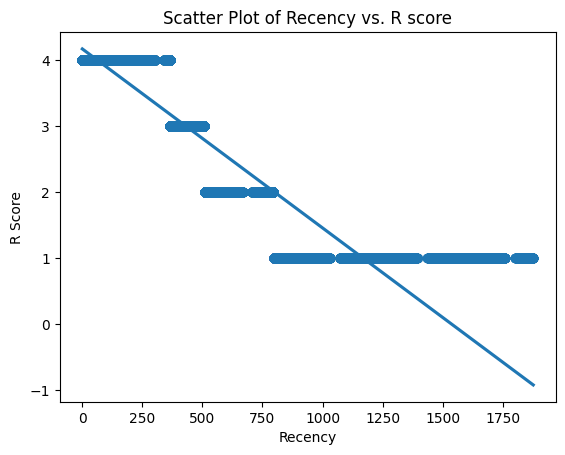

In [ ]:
sns.regplot(x=df_rfm['Recency'], y=df_rfm['R'], ci=None)  # ci=None untuk menghilangkan area interval kepercayaan (confidence interval)

# Menampilkan judul dan label
plt.title("Scatter Plot of Recency vs. R score")
plt.xlabel("Recency")
plt.ylabel("R Score")

# Menampilkan grafik
plt.savefig('Recency vs R Score.png')
plt.show()

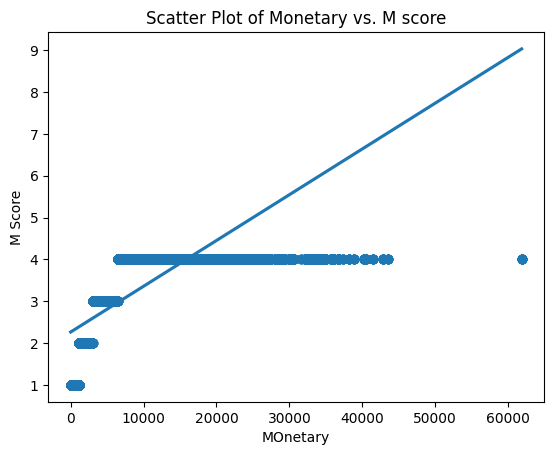

In [ ]:
sns.regplot(x=df_rfm['Monetary'], y=df_rfm['M'], ci=None)  # ci=None untuk menghilangkan area interval kepercayaan (confidence interval)

# Menampilkan judul dan label
plt.title("Scatter Plot of Monetary vs. M score")
plt.xlabel("MOnetary")
plt.ylabel("M Score")

# Menampilkan grafik
plt.savefig('Monetary vs M score')

plt.show()

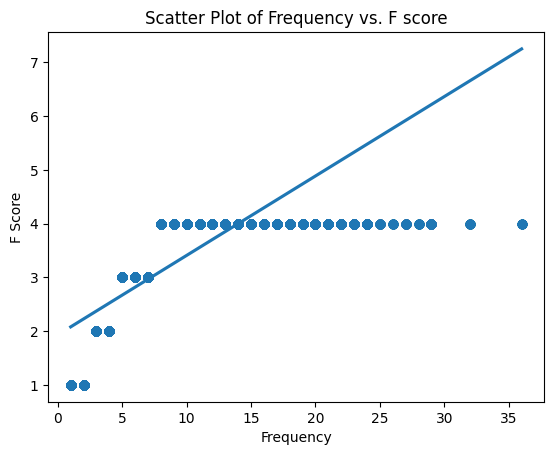

In [ ]:
sns.regplot(x=df_rfm['Frequency'], y=df_rfm['F'], ci=None)  # ci=None untuk menghilangkan area interval kepercayaan (confidence interval)

# Menampilkan judul dan label
plt.title("Scatter Plot of Frequency vs. F score")
plt.xlabel("Frequency")
plt.ylabel("F Score")

# Menampilkan grafik
plt.savefig('Scatter Plot Frequency vs F Score')
plt.show()

#Hypothesis Testing

## Total Score dengan Revenue

In [ ]:
# melakukan tes distribusi

from scipy import stats

# Cek normalitas
stat_total_score, p_total_score = stats.shapiro(df_rfm['Total_Score'])
stat_revenue, p_revenue = stats.shapiro(df_rfm['Revenue'])

print(f"Age normal? p-value: {p_total_score:.4f}")
print(f"Activity normal? p-value: {p_revenue:.4f}")

Age normal? p-value: 0.0000
Activity normal? p-value: 0.0000


/usr/local/lib/python3.13/dist-packages/scipy/stats/_axis_nan_policy.py:579: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 62884.
  res = hypotest_fun_out(*samples, **kwds)


karena p value < alfa berarti h0 ditolak, dan menerima h1, yang artinya data tidak berdistribusi normal

In [ ]:
corr, p_value = stats.spearmanr(df_rfm['Total_Score'], df_rfm['Revenue'])

print(f"Korelasi Spearman: {corr:.4f}")
print(f"p-value: {p_value:.4f}")

if p_value < 0.05:
    print("Tolak H0 - ada hubungan signifikan antara total score dengan revenue")
else:
    print("Gagal tolak H0 - tidak cukup bukti ada hubungan")



Korelasi Spearman: 0.0666
p-value: 0.0000
Tolak H0 - ada hubungan signifikan antara total score dengan revenue


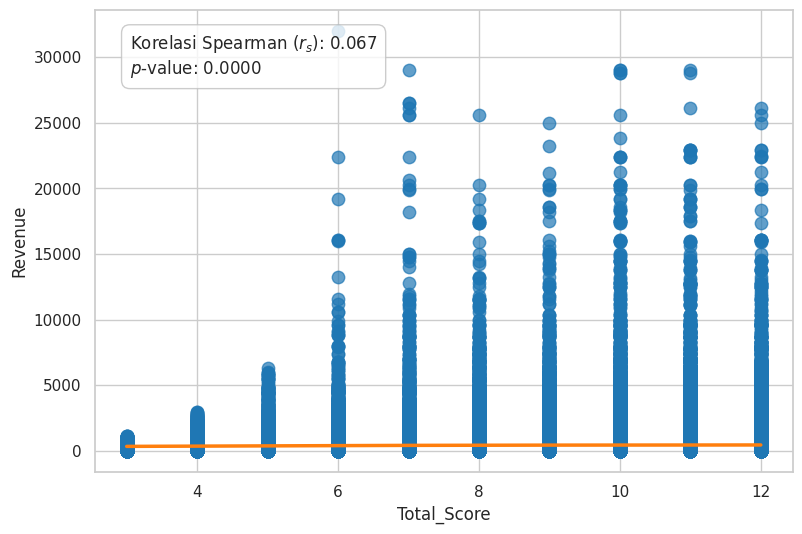

In [ ]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(9, 6))

sns.regplot(
    data=df_rfm,
    x='Total_Score',
    y='Revenue',
    lowess=True,  # Menggunakan estimasi non-parametrik yang cocok untuk data tidak normal
    scatter_kws={'s': 80, 'alpha': 0.7, 'color': '#1f77b4'},
    line_kws={'color': '#ff7f0e', 'linewidth': 2.5}
)


text_stats = f"Korelasi Spearman ($r_s$): {corr:.3f}\n$p$-value: {p_value:.4f}"
plt.gca().text(
    0.05, 0.95, text_stats,
    transform=plt.gca().transAxes,
    fontsize=12,
    verticalalignment='top',
    bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.8, edgecolor='silver')
)
plt.savefig('Hypothesis Total Score vs Revenue')



## M Score dengan Revenue

In [ ]:
# melakukan tes distribusi


# Cek normalitas
stat_m_score, p_m_score = stats.shapiro(df_rfm['M'])
stat_revenue, p_revenue = stats.shapiro(df_rfm['Revenue'])

print(f"Age normal? p-value: {p_m_score:.4f}")
print(f"Activity normal? p-value: {p_revenue:.4f}")

Age normal? p-value: 0.0000
Activity normal? p-value: 0.0000


karena p value < alfa berarti h0 ditolak, dan menerima h1, yang artinya data tidak berdistribusi normal

In [ ]:
corr, p_value = stats.spearmanr(df_rfm['M'], df_rfm['Revenue'])

print(f"Korelasi Spearman: {corr:.4f}")
print(f"p-value: {p_value:.4f}")

if p_value < 0.05:
    print("Tolak H0 - ada hubungan signifikan antara total score dengan revenue")
else:
    print("Gagal tolak H0 - tidak cukup bukti ada hubungan")

Korelasi Spearman: 0.1874
p-value: 0.0000
Tolak H0 - ada hubungan signifikan antara total score dengan revenue


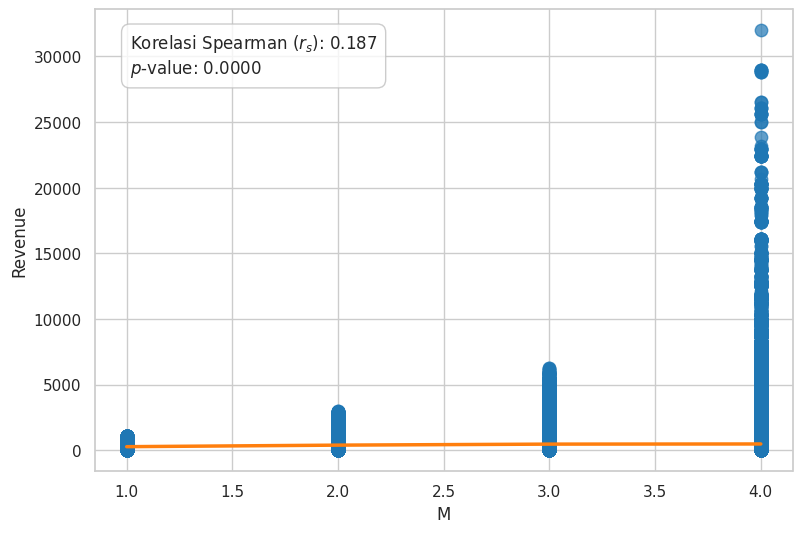

In [ ]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(9, 6))

sns.regplot(
    data=df_rfm,
    x='M',
    y='Revenue',
    lowess=True,  # Menggunakan estimasi non-parametrik yang cocok untuk data tidak normal
    scatter_kws={'s': 80, 'alpha': 0.7, 'color': '#1f77b4'},
    line_kws={'color': '#ff7f0e', 'linewidth': 2.5}
)


text_stats = f"Korelasi Spearman ($r_s$): {corr:.3f}\n$p$-value: {p_value:.4f}"
plt.gca().text(
    0.05, 0.95, text_stats,
    transform=plt.gca().transAxes,
    fontsize=12,
    verticalalignment='top',
    bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.8, edgecolor='silver')
)

plt.savefig('Hypothesis M Score vs Revenue')

